In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# MANIFESTO

In [2]:
from scripts.utils.logger import logger

In [3]:
logger_params = {
    "main_folder": "/home/think/Desktop/MOCK",
    "experiment_name": "LSTM_All",
    "date": "2025-09-27",
    "iteration": 1,
    "description": (
        "Se entrenara una LSTM con lorenz63 canonico caotico"
        "con distintos modos, univariable, y mutivariable,"
        "el proposito es que podamos dejar una plantilla"
    )
}

In [4]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/MOCK/LSTM_All_2025-09-27_iter1
Manifesto written to: /home/think/Desktop/MOCK/LSTM_All_2025-09-27_iter1/manifesto.txt


# DATA

In [5]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()[['x']]

# Train and Test Split
Full = sample['x'].values
n_samples = len(Full)
train_size = int(0.80 * n_samples)
train_data = Full[:train_size]
test_data = Full[train_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.reshape(-1, 1)).flatten()

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

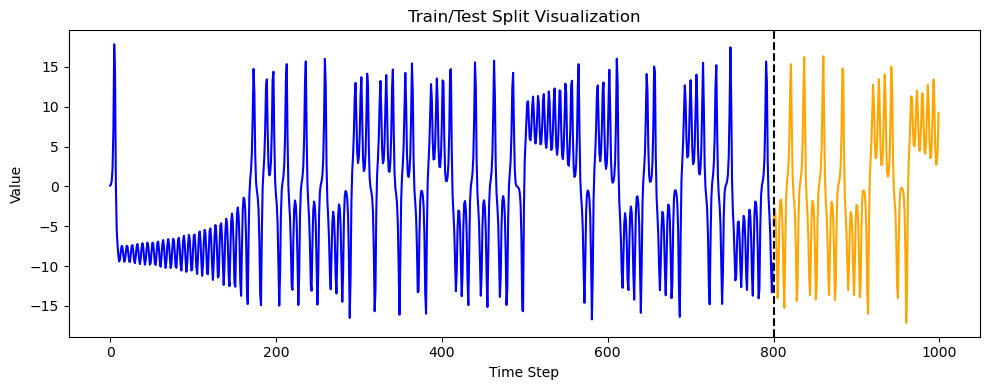

In [6]:
# Define x-axis ranges based on the lengths
train_end = len(train_data)
x_train = np.arange(train_end)
x_test = np.arange(train_end, train_end + len(test_data))
# Plot
plt.figure(figsize=(10, 4))
plt.plot(x_train, train_data, label='Train', color='blue')
plt.plot(x_test, test_data, label='Test', color='orange')

# Optional vertical line to indicate the split
plt.axvline(x=train_end, color='black', linestyle='--', label='Train/Test Split')

#plt.legend()
plt.title("Train/Test Split Visualization")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

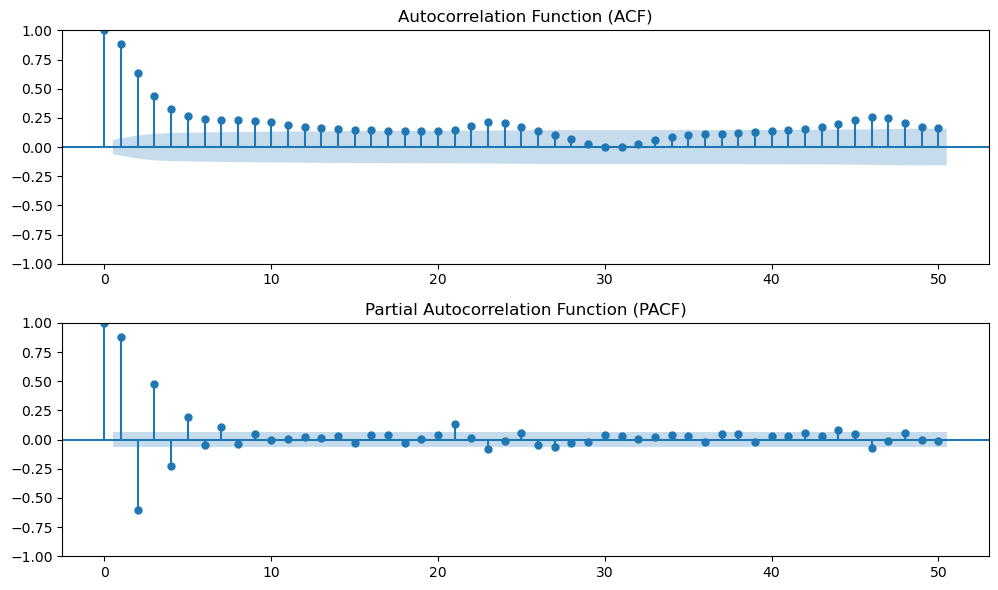

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(Full, lags=50, ax=ax[0])
ax[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(Full, lags=50, ax=ax[1], method="ywm")
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()


# LSTM - UNIVARIATE
Estamos usando la dimension x. Vamos a entrenar los modelos en el horizonte dado por la longitud de los datos de TEST.

### RECURSIVE 
Entrenamos solo UN modelo para predecir un paso adelante. Para un horizonte $H$, se predice el primer paso, esta predicción se usa como entrada para estimar el siguiente, y así sucesivamente hasta cubrir $H$.  

### Data Preparation

In [20]:
# univariate data preparation
from numpy import array
#split a univariate sequence into samples
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i +n_steps
        if end_ix > len(sequence) - 1:
            break
        #gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)
# choose a number of time steps
n_steps = 1
# split into samples
X, y = split_sequence(train_scaled, n_steps)  
# reshape from [samples, timesteps] into [samples, timestepsm features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

### Models

In [ ]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense

def vanilla_lstm(n_steps, n_features, units=100):
    """Return a compiled vanilla LSTM model."""
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps, n_features)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

2025-10-08 13:52:59.572042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759953179.592142  695193 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759953179.598254  695193 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759953179.614570  695193 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759953179.614592  695193 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759953179.614594  695193 computation_placer.cc:177] computation placer alr

In [ ]:
model_vanilla = vanilla_lstm(n_steps, n_features)
model_vanilla.fit(X, y, epochs=100, verbose=0)

In [ ]:
# Stacked
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense

def stacked_lstm(n_steps,n_features):
    # define model 
    model= Sequential()
    model.add(LSTM(100, activation='tanh', return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(LSTM(100, activation='tanh'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
# fit model
model_stacked = stacked_lstm(n_steps, n_features)
model_stacked.fit(X, y, epochs=100, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Scaler

In [ ]:
# We fit on train but immediately transform test here for simplicity
test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# If you want the prediction back in original units:
# yhat = scaler.inverse_transform(yhat_scaled)

### Teacher Forcing on Train Data

In [ ]:
import numpy as np

def teacher_forcing(data, model, scaler=None, inverse_output=True):
    """
    Teacher forcing predictions for LSTM models.
    
    Assumes `data` is already scaled to match model training.
    
    Parameters:
        data (np.array): Scaled input sequence.
        model (keras.Model): Trained LSTM model.
        scaler (sklearn scaler or None): Scaler used during training.
        inverse_output (bool): If True and scaler exists, inverse-transform predictions
                               to original units.
                               
    Returns:
        np.array: Predictions (scaled or original units).
    """
    predictions = []
    
    for i in range(len(data)):
        x = data[i].reshape((1, n_steps, n_features))
        yhat = model.predict(x, verbose=0)
        
        # Only inverse-transform if scaler exists and inverse_output=True
        if scaler is not None and inverse_output:
            yhat = scaler.inverse_transform(yhat)
        
        predictions.append(yhat[0, 0])
    
    return np.array(predictions)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_teacher_forcing(data_scaled, data_original, model, scaler=None, n_points=None, title='Teacher Forcing Forecast'):
    """
    Plot teacher forcing predictions for scaled and optionally unscaled outputs.
    
    Parameters:
        data_scaled (np.array): Scaled input sequence for the model.
        data_original (np.array): Original unscaled data (for comparison).
        model (keras.Model): Trained LSTM model.
        scaler (sklearn scaler or None): Scaler used for training, if you want unscaled output.
        n_points (int or None): Number of points to plot. If None, plot all.
        title (str): Plot title.
    """
    # Get predictions
    pred_unscaled = teacher_forcing(data_scaled, model, scaler=scaler, inverse_output=True)
    pred_scaled   = teacher_forcing(data_scaled, model, scaler=scaler, inverse_output=False)
    
    # Limit points for plotting if specified
    if n_points is not None:
        data_original = data_original[:n_points]
        pred_unscaled = pred_unscaled[:n_points]
        pred_scaled   = pred_scaled[:n_points]
    
    # Plot unscaled
    plt.figure(figsize=(15,5))
    plt.plot(data_original, label='Original', marker='.')
    plt.plot(pred_unscaled, label='Predicted (unscaled)', marker='*')
    plt.title(title + ' (Unscaled Output)')
    plt.legend()
    plt.show()
    
    # Plot scaled
    plt.figure(figsize=(15,5))
    plt.plot(data_scaled, label='Scaled Original', marker='.')
    plt.plot(pred_scaled, label='Predicted (scaled)', marker='*')
    plt.title(title + ' (Scaled Output)')
    plt.legend()
    plt.show()


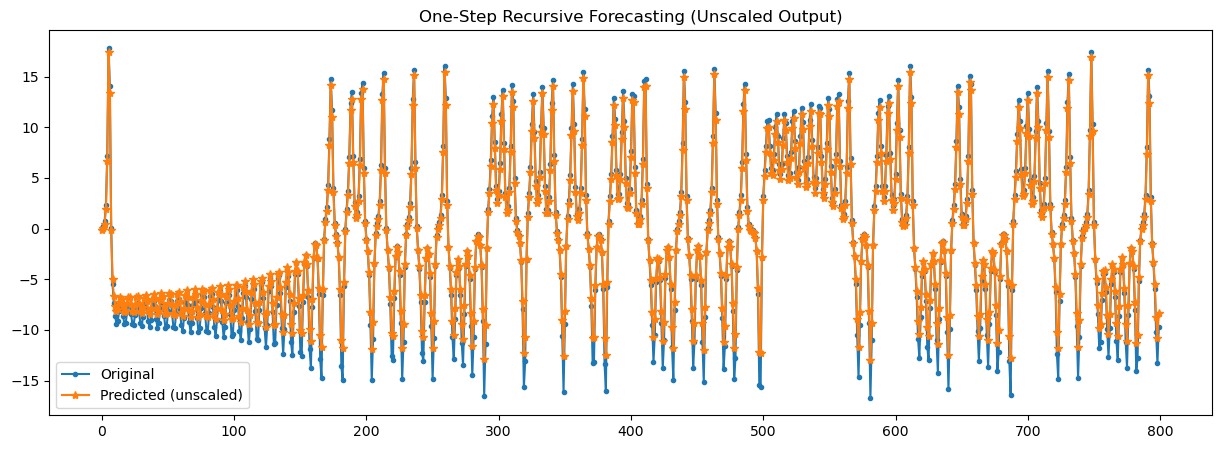

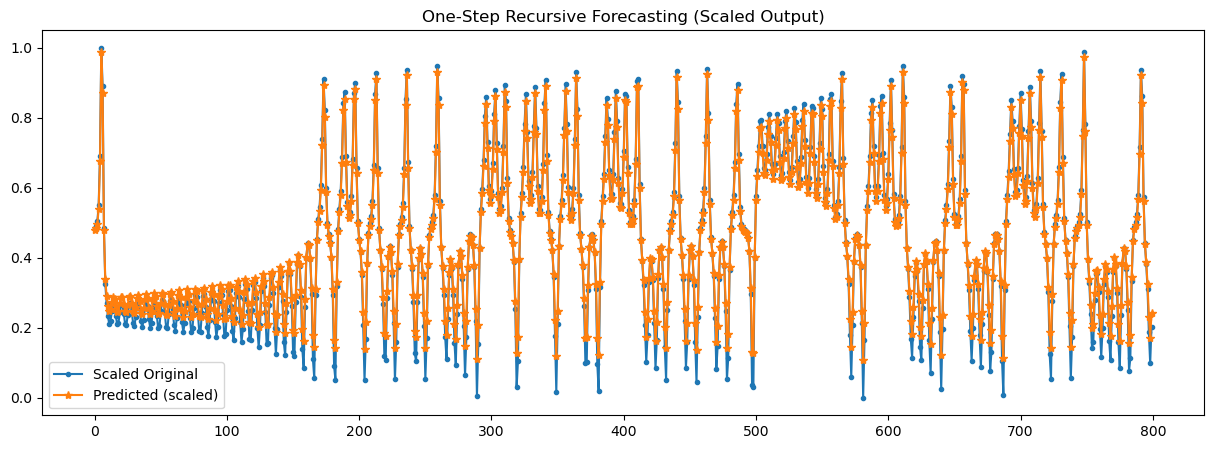

In [ ]:
plot_teacher_forcing(
    data_scaled=train_scaled,
    data_original=train_data,
    model=model_vanilla,
    scaler=scaler,
    n_points=None,   # optional, last 50 points
    title='One-Step Recursive Forecasting'
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

class TeacherForcingPlotter:
    def __init__(self, model, data_scaled, data_original, scaler=None):
        """
        Initialize the plotter.

        Parameters:
            model (keras.Model): Trained LSTM model.
            data_scaled (np.array): Input sequence for the model (scaled).
            data_original (np.array): Original unscaled sequence for comparison.
            scaler (sklearn scaler or None): Scaler used for training, for inverse-transforming outputs.
        """
        self.model = model
        self.data_scaled = data_scaled
        self.data_original = data_original
        self.scaler = scaler
        
        # Compute predictions
        self.pred_scaled = self._predict(inverse_output=False)
        self.pred_unscaled = self._predict(inverse_output=True)
        
        # Compute metrics
        self.metrics_scaled = self._compute_metrics(self.data_scaled, self.pred_scaled)
        self.metrics_unscaled = self._compute_metrics(self.data_original, self.pred_unscaled)
    
    def _predict(self, inverse_output=True):
        predictions = []
        for i in range(len(self.data_scaled)):
            x = self.data_scaled[i].reshape((1, n_steps, n_features))
            yhat = self.model.predict(x, verbose=0)
            if self.scaler is not None and inverse_output:
                yhat = self.scaler.inverse_transform(yhat)
            predictions.append(yhat[0, 0])
        return np.array(predictions)
    
    def _compute_metrics(self, true, pred):
        rmse = np.sqrt(mean_squared_error(true, pred))  # Compute RMSE manually
        mape = mean_absolute_percentage_error(true, pred) * 100
        return {'RMSE': rmse, 'MAPE': mape}
    
    def plot(self, title='Teacher Forcing Forecast'):
        # Plot unscaled
        plt.figure(figsize=(15,5))
        plt.plot(self.data_original, label='Original', marker='.')
        plt.plot(self.pred_unscaled, label=f'Predicted (unscaled)\nRMSE={self.metrics_unscaled["RMSE"]:.3f}, MAPE={self.metrics_unscaled["MAPE"]:.2f}%', marker='*')
        plt.title(title + ' (Unscaled Output)')
        plt.legend()
        plt.show()
        
        # Plot scaled
        plt.figure(figsize=(15,5))
        plt.plot(self.data_scaled, label='Scaled Original', marker='.')
        plt.plot(self.pred_scaled, label=f'Predicted (scaled)\nRMSE={self.metrics_scaled["RMSE"]:.3f}, MAPE={self.metrics_scaled["MAPE"]:.2f}%', marker='*')
        plt.title(title + ' (Scaled Output)')
        plt.legend()
        plt.show()


In [ ]:
# Create the object
tf_plotter = TeacherForcingPlotter(model_vanilla, train_scaled, train_data, scaler=scaler)

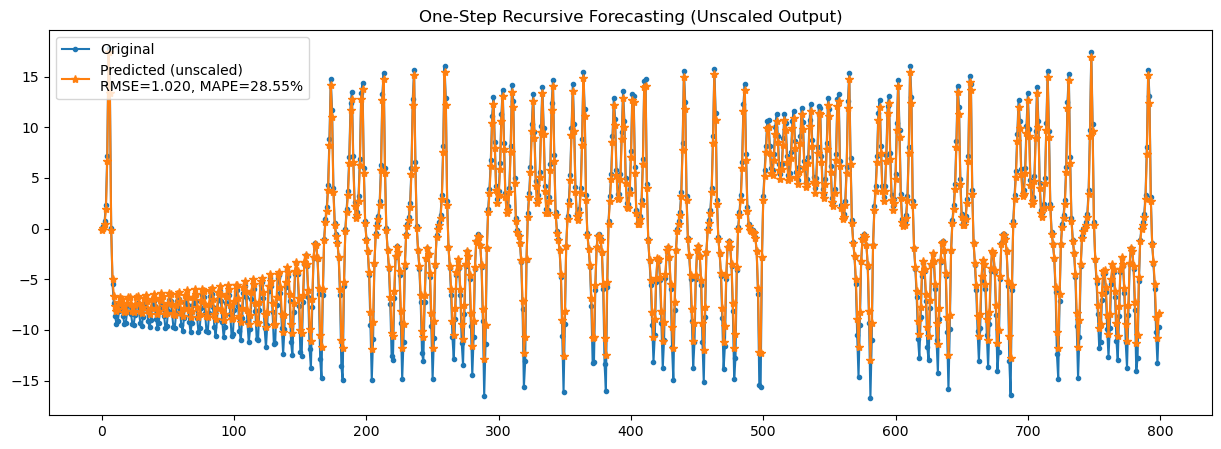

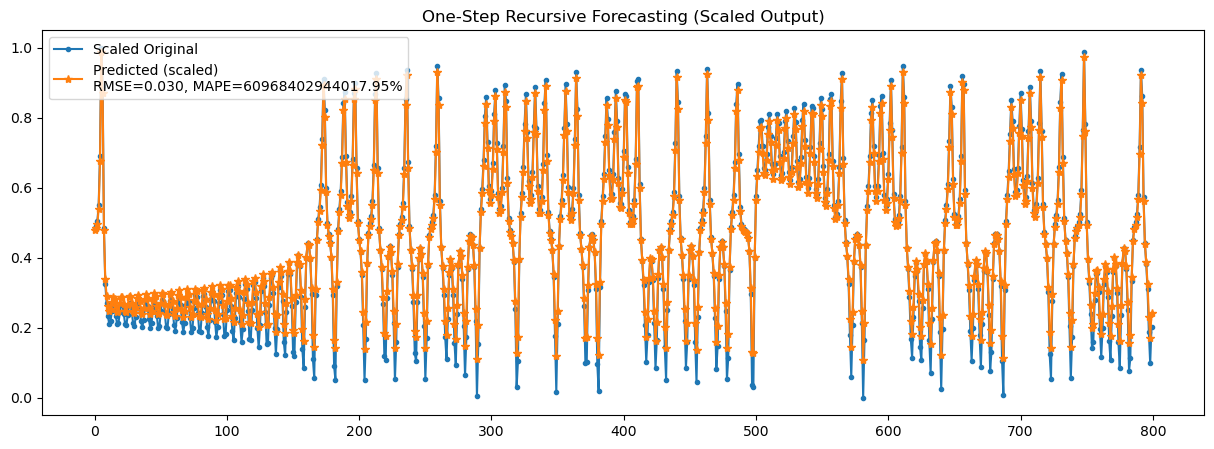

In [ ]:
# Plot
tf_plotter.plot('One-Step Recursive Forecasting')

In [ ]:
# Access metrics
print('Unscaled metrics:', tf_plotter.metrics_unscaled)
print('Scaled metrics:', tf_plotter.metrics_scaled)

Unscaled metrics: {'RMSE': 1.0200622749018529, 'MAPE': 28.545747864730693}
Scaled metrics: {'RMSE': 0.029529906829611895, 'MAPE': 60968402944017.95}


### Forecasting on Test Data

In [ ]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def recursive_OS_predictions(train_data_scaled, test_data, model, scaler = None):
    # Initialize input, start with the last value of the training data
    uno = train_data_scaled[-1].reshape((1, n_steps, n_features)) 
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(len(test_data)):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv[0, 0])
        else:
            predictions.append(yhat_scaled[0, 0])

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [ ]:
recurs_preds_1 = recursive_OS_predictions(train_scaled, test_data, model_vanilla, scaler = None)

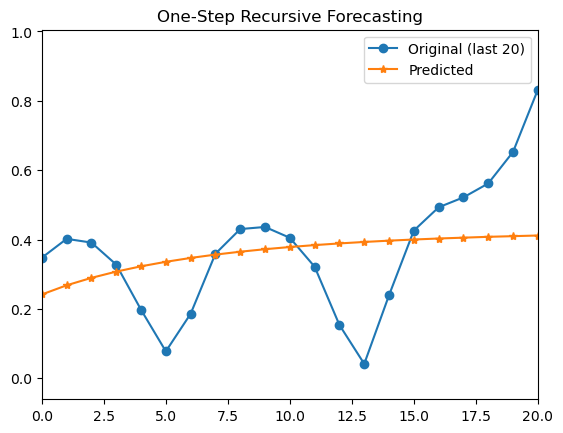

In [ ]:
# Plot
plt.plot(test_scaled, label='Original (last 20)', marker='o')
plt.plot(recurs_preds_1, label='Predicted', marker='*')
plt.legend()
plt.xlim(0,20)
plt.title('One-Step Recursive Forecasting')
plt.show()

In [ ]:
recurs_preds_1_stacked = recursive_OS_predictions(train_scaled, test_data, model_stacked, scaler = None)

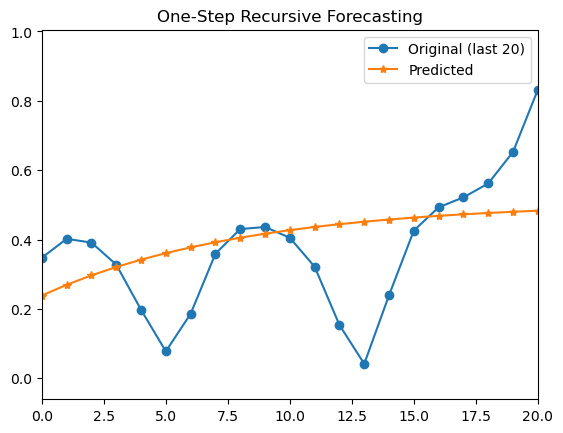

In [ ]:
# Plot
plt.plot(test_scaled, label='Original (last 20)', marker='o')
plt.plot(recurs_preds_1_stacked, label='Predicted', marker='*')
plt.legend()
plt.xlim(0,20)
plt.title('One-Step Recursive Forecasting')
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_forecast(predictions, real_data, limit=None):
    """
    Compute forecast metrics with an optional limit on how many points to evaluate.

    Args:
        predictions (array-like): Forecasted values (already inverse scaled if needed)
        real_data (array-like): Ground truth values (same scale as predictions)
        limit (int, optional): If set, only use the first `limit` points

    Returns:
        dict: RMSE, MAE, MAPE, and R²
    """
    preds = np.array(predictions)
    reals = np.array(real_data)

    # Trim if limit is specified
    if limit is not None:
        preds = preds[:limit]
        reals = reals[:limit]

    # Avoid NaN or zero divisions in MAPE
    mask = reals != 0
    reals_safe = reals[mask]
    preds_safe = preds[mask]

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(reals_safe, preds_safe))
    mae = mean_absolute_error(reals_safe, preds_safe)
    mape = np.mean(np.abs((reals_safe - preds_safe) / reals_safe)) * 100
    r2 = r2_score(reals_safe, preds_safe)

    metrics = {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

    return metrics


In [ ]:
# Evaluate normally
print(evaluate_forecast(recurs_preds_1_stacked, test_scaled))

{'RMSE': 0.22423357322890125, 'MAE': 0.18196888377024426, 'MAPE': 107.272711282548, 'R2': 0.03404546222692795}


In [ ]:
# Evaluate normally
print(evaluate_forecast(recurs_preds_1_stacked, test_scaled, limit = 20))

{'RMSE': 0.16331758529264664, 'MAE': 0.12319064780077653, 'MAPE': 101.32685756644561, 'R2': -0.09957425148534305}


In [ ]:
# Evaluate normally
print(evaluate_forecast(recurs_preds_1, test_scaled))

{'RMSE': 0.2348998129278483, 'MAE': 0.1909583898664495, 'MAPE': 92.76212145541774, 'R2': -0.060036339308098485}


In [ ]:
# Evaluate normally
print(evaluate_forecast(recurs_preds_1, test_scaled, limit = 20))

{'RMSE': 0.15324926322897234, 'MAE': 0.12499261242725783, 'MAPE': 90.67779899634965, 'R2': 0.0318214607307874}


# DIRECT
Entrenar $H$ modelos, cada uno especializado en un paso del horizonte. El modelo 1 predice el paso 1, el modelo 2 el paso 2, y así hasta el modelo $H$ que predice el último.

OKay, i am trying to implement DIrect Strategy and i relaized that we can start with like lets say 10 points of data, and like a horixon of 3 outside points we will be training this model to predict different temporal positions, even though tthey will be trained on the same data, so like ok that is it

In [191]:
# univariate data preparation
from numpy import array

In [229]:
#split a univariate sequence into samples
def split_sequence_direct(sequence, n_steps, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i +n_steps 
        # print(end_ix)
        if end_ix > len(sequence) - 1 - skip:
            break
        #gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix+skip]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [230]:
# define input sequence
raw_seq = array([i for i in range(1, 210, 1)])
horizon = 3


In [231]:
raw_seq

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [232]:
# choose a number of time steps
n_steps = 1
skip = horizon - 1
# split into samples
X, y = split_sequence_direct(raw_seq, n_steps,skip)   

In [233]:
y

array([  4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,
        17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,
        30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172,
       173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 18

In [234]:
# summarize the data
for i in range(len(X)):
    print(X[i], y[i])

[1] 4
[2] 5
[3] 6
[4] 7
[5] 8
[6] 9
[7] 10
[8] 11
[9] 12
[10] 13
[11] 14
[12] 15
[13] 16
[14] 17
[15] 18
[16] 19
[17] 20
[18] 21
[19] 22
[20] 23
[21] 24
[22] 25
[23] 26
[24] 27
[25] 28
[26] 29
[27] 30
[28] 31
[29] 32
[30] 33
[31] 34
[32] 35
[33] 36
[34] 37
[35] 38
[36] 39
[37] 40
[38] 41
[39] 42
[40] 43
[41] 44
[42] 45
[43] 46
[44] 47
[45] 48
[46] 49
[47] 50
[48] 51
[49] 52
[50] 53
[51] 54
[52] 55
[53] 56
[54] 57
[55] 58
[56] 59
[57] 60
[58] 61
[59] 62
[60] 63
[61] 64
[62] 65
[63] 66
[64] 67
[65] 68
[66] 69
[67] 70
[68] 71
[69] 72
[70] 73
[71] 74
[72] 75
[73] 76
[74] 77
[75] 78
[76] 79
[77] 80
[78] 81
[79] 82
[80] 83
[81] 84
[82] 85
[83] 86
[84] 87
[85] 88
[86] 89
[87] 90
[88] 91
[89] 92
[90] 93
[91] 94
[92] 95
[93] 96
[94] 97
[95] 98
[96] 99
[97] 100
[98] 101
[99] 102
[100] 103
[101] 104
[102] 105
[103] 106
[104] 107
[105] 108
[106] 109
[107] 110
[108] 111
[109] 112
[110] 113
[111] 114
[112] 115
[113] 116
[114] 117
[115] 118
[116] 119
[117] 120
[118] 121
[119] 122
[120] 123
[121] 124


In [235]:
# choose a number of time steps
n_steps = 1
skip = horizon 
datasets = {}
for i in range(skip):
    X, y = split_sequence_direct(raw_seq, n_steps, i)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    datasets[i] = (X, y)  # store as tuple
# for i in range(skip):
#     # split into samples
#     X, y = split_sequence_direct(raw_seq, n_steps,i)   
#     # reshape from [samples, timesteps] into [samples, timestepsm features]
#     n_features = 1
#     X = X.reshape((X.shape[0], X.shape[1], n_features))
#     datasets[f'X_{i}'] = X
#     datasets[f'y_{i}'] = y

In [247]:
X, y = datasets[0]
for xi, yi in zip(X, y):
    print(xi,yi)


[[1]] 2
[[2]] 3
[[3]] 4
[[4]] 5
[[5]] 6
[[6]] 7
[[7]] 8
[[8]] 9
[[9]] 10
[[10]] 11
[[11]] 12
[[12]] 13
[[13]] 14
[[14]] 15
[[15]] 16
[[16]] 17
[[17]] 18
[[18]] 19
[[19]] 20
[[20]] 21
[[21]] 22
[[22]] 23
[[23]] 24
[[24]] 25
[[25]] 26
[[26]] 27
[[27]] 28
[[28]] 29
[[29]] 30
[[30]] 31
[[31]] 32
[[32]] 33
[[33]] 34
[[34]] 35
[[35]] 36
[[36]] 37
[[37]] 38
[[38]] 39
[[39]] 40
[[40]] 41
[[41]] 42
[[42]] 43
[[43]] 44
[[44]] 45
[[45]] 46
[[46]] 47
[[47]] 48
[[48]] 49
[[49]] 50
[[50]] 51
[[51]] 52
[[52]] 53
[[53]] 54
[[54]] 55
[[55]] 56
[[56]] 57
[[57]] 58
[[58]] 59
[[59]] 60
[[60]] 61
[[61]] 62
[[62]] 63
[[63]] 64
[[64]] 65
[[65]] 66
[[66]] 67
[[67]] 68
[[68]] 69
[[69]] 70
[[70]] 71
[[71]] 72
[[72]] 73
[[73]] 74
[[74]] 75
[[75]] 76
[[76]] 77
[[77]] 78
[[78]] 79
[[79]] 80
[[80]] 81
[[81]] 82
[[82]] 83
[[83]] 84
[[84]] 85
[[85]] 86
[[86]] 87
[[87]] 88
[[88]] 89
[[89]] 90
[[90]] 91
[[91]] 92
[[92]] 93
[[93]] 94
[[94]] 95
[[95]] 96
[[96]] 97
[[97]] 98
[[98]] 99
[[99]] 100
[[100]] 101
[[101]] 102
[[

In [237]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense

def vanilla_lstm(n_steps, n_features, units=100):
    """Return a compiled vanilla LSTM model."""
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps, n_features)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [238]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps, n_features)
    model.fit(X, y, epochs=500, verbose=0)
    models[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [253]:
x_input = array([283])
x_input = x_input.reshape((1, n_steps, n_features))
predictions = []

for i in range(skip):  # skip = number of horizons / models
    model = models[i]
    yhat = model.predict(x_input, verbose=0)
    predictions.append(yhat[0, 0])  # flatten the output

# yhat = model.predict(x_input, verbose=0)

In [254]:
predictions

[283.9627, 284.30807, 286.0475]

# DIREC
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$. Se entrena un modelo para predecir $B$ pasos, y la predicción del bloque se reutiliza como entrada del siguiente bloque hasta alcanzar $H$.  


In [141]:
# univariate data preparation
from numpy import array
#  split a univariate sequence into samples
def split_sequence_direc(sequence, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # print(i,end_ix)
        # print(end_ix,out_end_ix)
        # check if we are beyond the sequence
        if out_end_ix > len(sequence)- skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[skip+end_ix:skip + out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [142]:
# define input sequence
raw_seq = array([i for i in range(10, 100, 10)])
print(raw_seq)

[10 20 30 40 50 60 70 80 90]


In [143]:
# choose a number of time steps
n_steps_in = 3
n_steps_out = 3
skip=0
# split into samples
X, y = split_sequence_direc(raw_seq, n_steps_in, n_steps_out, skip)   

In [144]:
# summarize the data
for i in range(len(X)):
    print(X[i], y[i])

[10 20 30] [40 50 60]
[20 30 40] [50 60 70]
[30 40 50] [60 70 80]
[40 50 60] [70 80 90]


In [145]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [146]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_direct(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [147]:
model_direc = vanilla_lstm_direct(n_steps_in, n_steps_out,n_features)
model_direc.fit(X, y, epochs=800, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [148]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def direc_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    n_steps_in = len(starter_sample)
    uno = starter_sample.reshape((1, n_steps_in, n_features)) 
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(0, horizon, len(starter_sample)):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv)
        else:
            predictions.append(yhat_scaled)

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [149]:
starter_sample = array([70,80,90])
horizon = 9 
direc_preds = direc_predictions(starter_sample, horizon, model_direc, scaler = None)

In [150]:
direc_preds

array([[[105.74379, 114.41084, 128.38077]],

       [[152.54512, 161.5566 , 185.08893]],

       [[218.04779, 230.12291, 267.3341 ]]], dtype=float32)

In [151]:
horizon_array = array([i for i in range(100, 200, 10)])
print(horizon_array)

[100 110 120 130 140 150 160 170 180 190]


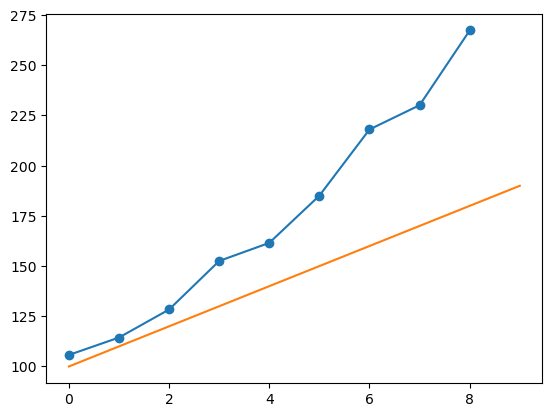

In [152]:
import matplotlib.pyplot as plt
plt.plot(direc_preds.flatten(), marker='o')
plt.plot(horizon_array)
plt.show()

# MIMO
Entrenar un único modelo capaz de predecir directamente los $H$ pasos en una sola iteración.  

In [153]:
# split a univariate sequence into samples
def split_sequence(sequence, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [154]:
# define input sequence
raw_seq = array([i for i in range(10, 100, 10)])

In [155]:
# choose a number of time steps
n_steps_in = 1
n_steps_out = 4
# split into samples
X, y = split_sequence(raw_seq, n_steps_in, n_steps_out)   

In [156]:
# summarize the data
for i in range(len(X)):
    print(X[i], y[i])

[10] [20 30 40 50]
[20] [30 40 50 60]
[30] [40 50 60 70]
[40] [50 60 70 80]
[50] [60 70 80 90]


In [157]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

In [158]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_direct(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [159]:
model_direc = vanilla_lstm_direct(n_steps_in, n_steps_out,n_features)
model_direc.fit(X, y, epochs=800, verbose=0)

In [162]:
# demonstrate prediction
x_input = array([100])
x_input = x_input.reshape((1, n_steps_in, n_features))
yhat = model_direc.predict(x_input, verbose = 0)
print(yhat)

[[109.03464 126.11861 147.8854  177.1606 ]]


# DIRMO
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$, y entrenar $N$ modelos, cada uno encargado de predecir $B$ pasos consecutivos. 


In [179]:
# univariate data preparation
from numpy import array
#  split a univariate sequence into samples
def split_sequence_dirMO(sequence, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this patter
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # print(i,end_ix)
        # print(end_ix,out_end_ix)
        # check if we are beyond the sequence
        if out_end_ix > len(sequence)- skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[skip+end_ix:skip + out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [206]:
# define input sequence
raw_seq = array([i for i in range(1, 210, 1)])
horizon = 9

In [181]:
# choose a number of time steps
n_steps_in = 3
n_steps_out = 3
skip = horizon 
datasets = {}
for i in range(skip):
    X, y = split_sequence_dirMO(raw_seq, n_steps_in, n_steps_out, i)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    datasets[i] = (X, y)  # store as tuple

In [182]:
X, y = datasets[2]
for xi, yi in zip(X, y):
    print(xi,yi)


[[1]
 [2]
 [3]] [6 7 8]
[[2]
 [3]
 [4]] [7 8 9]
[[3]
 [4]
 [5]] [ 8  9 10]
[[4]
 [5]
 [6]] [ 9 10 11]
[[5]
 [6]
 [7]] [10 11 12]
[[6]
 [7]
 [8]] [11 12 13]
[[7]
 [8]
 [9]] [12 13 14]
[[ 8]
 [ 9]
 [10]] [13 14 15]
[[ 9]
 [10]
 [11]] [14 15 16]
[[10]
 [11]
 [12]] [15 16 17]
[[11]
 [12]
 [13]] [16 17 18]
[[12]
 [13]
 [14]] [17 18 19]
[[13]
 [14]
 [15]] [18 19 20]
[[14]
 [15]
 [16]] [19 20 21]
[[15]
 [16]
 [17]] [20 21 22]
[[16]
 [17]
 [18]] [21 22 23]
[[17]
 [18]
 [19]] [22 23 24]
[[18]
 [19]
 [20]] [23 24 25]
[[19]
 [20]
 [21]] [24 25 26]
[[20]
 [21]
 [22]] [25 26 27]
[[21]
 [22]
 [23]] [26 27 28]
[[22]
 [23]
 [24]] [27 28 29]
[[23]
 [24]
 [25]] [28 29 30]
[[24]
 [25]
 [26]] [29 30 31]
[[25]
 [26]
 [27]] [30 31 32]
[[26]
 [27]
 [28]] [31 32 33]
[[27]
 [28]
 [29]] [32 33 34]
[[28]
 [29]
 [30]] [33 34 35]
[[29]
 [30]
 [31]] [34 35 36]
[[30]
 [31]
 [32]] [35 36 37]
[[31]
 [32]
 [33]] [36 37 38]
[[32]
 [33]
 [34]] [37 38 39]
[[33]
 [34]
 [35]] [38 39 40]
[[34]
 [35]
 [36]] [39 40 41]
[[35]
 

In [ ]:
# Vanilla
from keras.models import Sequential
from keras.layers import LSTM, Dense
def vanilla_lstm_dirMO(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

In [186]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm_direct(n_steps_in, n_steps_out, n_features, units = 100)
    model.fit(X, y, epochs=500, verbose=0)
    models[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [202]:
x_input = array([207,208,209])
x_input = x_input.reshape((1, n_steps_in, n_features))
i=0
yhat = models[i].predict(x_input, verbose=0)
print(yhat)

[[210.009   211.02208 212.00203]]


In [203]:
x_input = array([207,208,209])
x_input = x_input.reshape((1, n_steps_in, n_features))
i=1
yhat = models[i].predict(x_input, verbose=0)
print(yhat)

[[210.99072 211.97766 212.94925]]


In [211]:
x_input = array([207,208,209])
x_input = x_input.reshape((1, n_steps_in, n_features))
i=2
yhat = models[i].predict(x_input, verbose=0)
print(yhat)

[[212.06128 213.07082 214.071  ]]


In [212]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np
# Initialize input
starter_sample = array([207,208,209])
n_steps_in = len(starter_sample)
uno = starter_sample.reshape((1, n_steps_in, n_features)) 
# List to store predictions
predictions = []
# Loop to predict one step at a time
for i in range(0, len(starter_sample)):
    print(i)
    model = models[i]
    yhat_scaled = model.predict(uno, verbose=0) 
    predictions.append(yhat_scaled)

    # Feed back the scaled value to the model
    uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 

# Convert predictions to numpy array
predictions = np.array(predictions)

# for i in range(skip):  # skip = number of horizons / models
#     model = models[i]
#     yhat = model.predict(x_input, verbose=0)
#     predictions.append(yhat[0, 0])  # flatten the output

# # yhat = model.predict(x_input, verbose=0)


0
1
2


In [213]:
predictions

array([[[210.009  , 211.02208, 212.00203]],

       [[213.99913, 214.9824 , 215.94664]],

       [[219.07425, 220.08633, 221.08932]]], dtype=float32)